In [8]:
import pandas as pd
import numpy as np
import torch
all_data = pd.read_csv('../examples/reference_LUAD.csv')
row = all_data[[x for x in all_data.keys() if x != 'rna_file_name']]
rna_data = row[[x for x in row.keys() if 'rna_' in x]].values.astype(np.float32)
# Apply log2(v + 1) transform so high-abundance genes do not dominate the MSE loss
rna_data = np.log2(rna_data + 1.0, out=rna_data)


In [9]:
print(rna_data.shape)

(536, 20820)


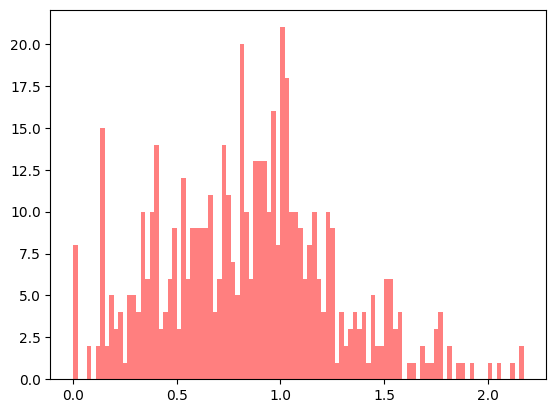

In [7]:
rna1 = rna_data[:, 1000]
# hist plot
import matplotlib.pyplot as plt
# plt.hist(rna1, bins=100, alpha=0.5, color='blue')
plt.hist(np.log2(rna1 + 1.0), bins=100, alpha=0.5, color='red')
plt.show()


In [10]:
a = np.mean(rna_data, axis=0)
print(a.shape)
print(a)
# np.save('../examples/CPTAC_COAD_rna_data_mean.npy', a)

(20820,)
[0.06241517 0.4001984  7.002014   ... 5.6682587  2.1110363  2.4548573 ]


In [13]:
print(sorted(a)[-10:])

[11.383624, 11.423966, 11.430547, 11.555719, 11.617804, 12.236726, 12.277867, 12.386816, 12.458098, 12.513947]


In [11]:
b = np.std(rna_data, axis=0)
print(b.shape)
print(b)
# np.save('../examples/CPTAC_COAD_rna_data_std.npy', b)

(20820,)
[0.05622073 0.2607581  1.14344    ... 0.74300104 0.48803017 0.3934571 ]


In [14]:
print(sorted(b)[-10:])

[2.5715506, 2.6478739, 2.6529686, 2.7602234, 2.7830305, 2.9436927, 2.9984405, 3.0517786, 3.0837414, 3.098022]


/tmp/ipykernel_3975437/1683612362.py:1: RuntimeWarning: invalid value encountered in divide
  norm = (rna_data - a) / b


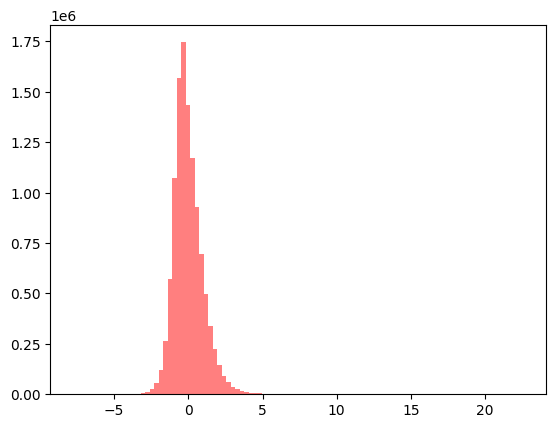

In [15]:
norm = (rna_data - a) / b
# print(norm.shape)
# print(norm)
# print(norm.min(), norm.max())
# print(norm.mean(), norm.std())
# print(norm.var())
import matplotlib.pyplot as plt
# plt.hist(rna1, bins=100, alpha=0.5, color='blue')
plt.hist(norm.flatten(), bins=100, alpha=0.5, color='red')
plt.show()


In [9]:
a[7038]

0.0

In [14]:
np.sort(b)[:10]

array([0.        , 0.00087178, 0.00260409, 0.00324436, 0.00631109,
       0.00665587, 0.00674121, 0.00684291, 0.0075221 , 0.00885473],
      dtype=float32)